In [37]:
import random
import gymnasium as gym
from collections import namedtuple, deque
from itertools import count
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.tensorboard import SummaryWriter
# Initialize TensorBoard writer
writer = SummaryWriter()
BASE_MODEL_PATH = "ddqn_lunar_lander_base_actions.pth"
NUMBER_OF_EPISODES = 600
Transition = namedtuple(
    "Transition", ["state", "action", "next_state", "reward", "done"]
)
class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return (
            random.sample(self.memory, batch_size)
            if batch_size < len(self.memory)
            else self.memory
        )

    def __len__(self):
        return len(self.memory)

In [38]:
# !pip install swig
# !pip install "gymnasium[box2d]"

In [39]:
import torch.nn as nn
import torch.nn.functional as F


class DQN(nn.Module):
    def __init__(self, n_observations, n_actions):
        super().__init__()
        self.layer1 = nn.Linear(n_observations, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, n_actions)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)


In [40]:
class ActionMap():
    def __init__(self, action_map = {0:1, 1:2, 2:3}, expand_actions_env = []):
        self.action_map = action_map
        self.expand_actions_env = expand_actions_env
    
    def convert_action_env_to_network(self, action_env):
        for k, v in self.action_map.items():
            if v == action_env:
                return k
        return None
    
    def get_expand_action_in_network(self):
        result = []
        for i in self.expand_actions_env:
            net_action = self.convert_action_env_to_network(i)
            result.append(net_action)
        return result
                
    def convert_network_action_to_env(self, action_network):
        return self.action_map.get(action_network, None)
    
    def select_all_actions_in_network(self):
        return list(self.action_map.keys())
    def select_all_actions_in_env(self):
        return list(self.action_map.values())

In [41]:
class DDQNAgent:
    def __init__(self, n_observation, action_data: ActionMap, batch_size=128, gamma=0.99, lr=1e-4, tau=0.005):
        action_len = len(action_data.action_map.keys())
        self.policy_net = DQN(n_observations= n_observation, n_actions=action_len)
        self.target_net = DQN(n_observations= n_observation, n_actions=action_len)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.batch_size = batch_size
        self.GAMMA = gamma
        self.LR = lr
        self.TAU = tau
        self.action_map = action_data
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.policy_net = DQN(n_observations= n_observation, n_actions= action_len).to(self.device)
        self.target_net = DQN(n_observations= n_observation, n_actions= action_len).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.replay_memory = ReplayMemory(10000)
        self.reward_list = []
        self.episode_duration = []
        self.optimizer = optim.AdamW(self.policy_net.parameters(), lr=self.LR)
        self.criterion = nn.SmoothL1Loss()
        self.EPSILON = 1.0
        self.EPSILON_MIN = 0.01
        self.EPSILON_DECAY = 0.995
    def select_action(self, state, epsilon):
        if np.random.rand() < epsilon:
            action = np.random.choice(self.action_map.select_all_actions_in_network())
            return torch.tensor([[action]], dtype=torch.long, device=self.device)
        else:
            with torch.no_grad():
                return self.policy_net(state).max(1).indices.view(1, 1) # max row (1), max col (0)
            
    def train(self, env, num_episodes):
        for episode in range(num_episodes):
            total_reward = 0
            state, _ = env.reset()
            state = torch.tensor(
                state, dtype=torch.float32, device=self.device
            ).unsqueeze(0)
            for t in count():
                
                action = self.select_action(state, self.EPSILON)
                env_action = self.action_map.convert_network_action_to_env(action.item())
                next_state, reward, terminated, truncated, info = env.step(env_action)
                done = terminated or truncated
                reward = torch.tensor([reward], device=self.device)
                next_state = torch.tensor(
                    next_state, dtype=torch.float32, device=self.device
                ).unsqueeze(0)
                self.replay_memory.push(state, action, next_state, reward, done)
                state = next_state
                total_reward += reward.item()
                if len(self.replay_memory) >= self.batch_size:
                    transitions = self.replay_memory.sample(self.batch_size)
                    states, actions, next_states, rewards, dones = zip(*transitions) 
                    #convert tuple to tensor array
                    states_batch = torch.cat(states) # states is a tuple, now it becomes a batch (2D array)
                    next_states_batch = torch.cat(next_states)
                    actions_batch = torch.cat(actions)
                    
                    reward_batch = torch.tensor(rewards, device= self.device)
                    dones_batch = torch.tensor(dones, dtype=torch.float32, device=self.device)
                    
                    # Q-value which are estimating (policy network)
                    q_values = self.policy_net(states_batch).gather(1, actions_batch).squeeze()
                    
                    # get target Q-values
                    with torch.no_grad():
                        next_q_values = self.target_net(next_states_batch).max(1).values
                        target_q_values = reward_batch + self.GAMMA * next_q_values * (1 - dones_batch)
                    loss = self.criterion(q_values, target_q_values) # prove converge
                    
                    self.optimizer.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
                    self.optimizer.step()
                    
                    # soft update target network
                    for target_param, policy_param in zip(self.target_net.parameters(), self.policy_net.parameters()):
                        target_param.data.copy_(self.TAU * policy_param.data + (1 - self.TAU) * target_param.data)
                    
                if done:
                    self.episode_duration.append(t+1)
                    break
            
            # Decay epsilon    
            self.EPSILON = max(self.EPSILON_MIN, self.EPSILON * self.EPSILON_DECAY)
            self.reward_list.append(total_reward)
            
            if (episode + 1) % 10 == 0:
                avg_reward = np.mean(self.reward_list[-10:])
                print(f"Episode {episode+1}/{num_episodes}, Reward: {total_reward:.2f}, "
                    f"Avg10: {avg_reward:.2f}, Epsilon: {self.EPSILON:.3f}")                    
        
        torch.save(self.policy_net.state_dict(), BASE_MODEL_PATH)            
                    

### Train the Transition Model

TRANSITION MODEL FOR ACTION 0 (NOOP)
With Early Stopping and Regularization
Using device: cpu

--- Regularization Settings ---
Dropout: 0.2
Weight Decay: 0.0001
Early Stopping Patience: 20

Collected 4684 transitions for action 0
Training samples: 3747
Testing samples: 937

Training for up to 100 epochs (early stopping enabled)...
Epoch  10/100 | Train Loss: -1.5411 | Test Loss: -2.0409 | Train MSE: 0.048141 | Test MSE: 0.030781 | No improvement: 0
Epoch  20/100 | Train Loss: -1.9308 | Test Loss: -2.2197 | Train MSE: 0.048356 | Test MSE: 0.031581 | No improvement: 8
Epoch  30/100 | Train Loss: -1.9226 | Test Loss: -2.1529 | Train MSE: 0.047756 | Test MSE: 0.032294 | No improvement: 18

*** Early stopping at epoch 32 (no improvement for 20 epochs) ***

Loaded best model from epoch 12 (Test MSE: 0.030780)
Model saved to transition_model_action0.pth


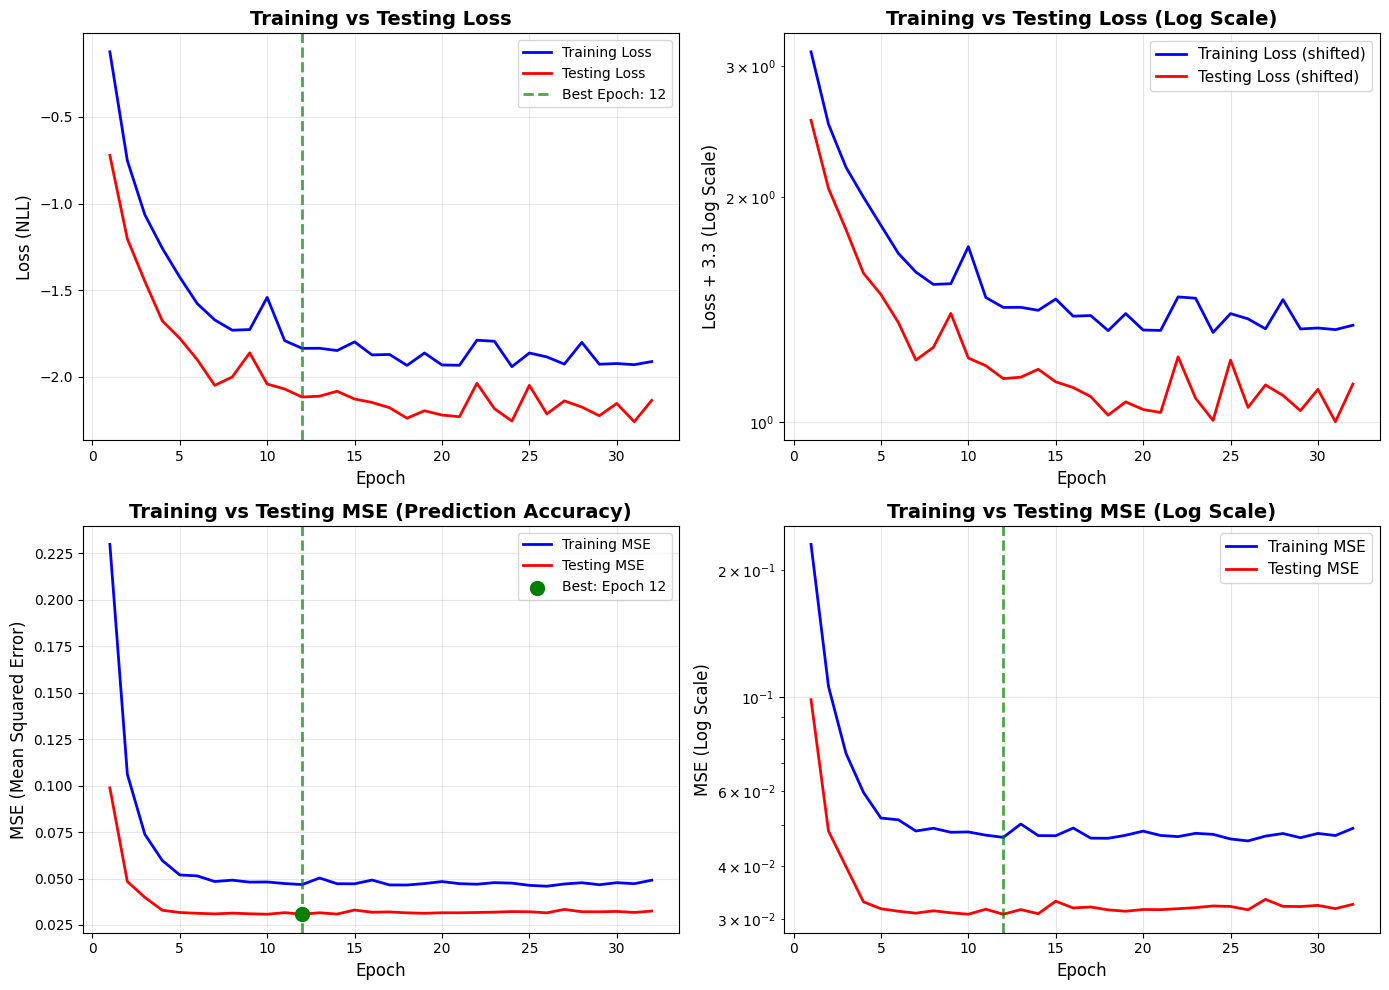


OVERFITTING CHECK SUMMARY

--- Loss (NLL) ---
Final Training Loss: -1.911235
Final Testing Loss:  -2.134760

--- MSE (Prediction Accuracy) ---
Final Training MSE:  0.049103
Final Testing MSE:   0.032477
Best Testing MSE:    0.030780 (Epoch 12)
Final RMSE:          0.180214

--- Early Stopping ---
Best model saved at: Epoch 12

--- Overfitting Analysis ---
MSE Gap (Test - Train): -0.016626

✅ Model generalizes well!
   Test MSE is actually better than train MSE.

Results saved to 'transition_model_overfitting.png'


In [42]:
"""
Transition Model for Action 0 (NOOP/Nothing)
=============================================

This MLP predicts: s' = f(s, a=0)
Given current state s, predict next state s' when taking action 0 (do nothing).

The model learns from real transitions collected when action 0 is executed.
"""

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from collections import deque
import gymnasium as gym


class TransitionModelAction0(nn.Module):
    """
    MLP to predict next state for action 0 (NOOP).
    
    Input: state s (8-dim for LunarLander)
    Output: predicted next state s' (8-dim)
    
    Optionally outputs variance for uncertainty estimation.
    """
    
    def __init__(self, state_dim=8, hidden_dim=128, with_variance=True, dropout=0.2):
        super().__init__()
        
        self.state_dim = state_dim
        self.with_variance = with_variance
        
        # Shared layers with dropout for regularization
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        
        # Dropout for regularization
        self.dropout = nn.Dropout(dropout)
        
        # Mean prediction (next state)
        self.fc_mean = nn.Linear(hidden_dim, state_dim)
        
        # Variance prediction (for uncertainty/confidence)
        if with_variance:
            self.fc_logvar = nn.Linear(hidden_dim, state_dim)
        
        self.relu = nn.ReLU()
        
    def forward(self, state):
        """
        Forward pass.
        
        Args:
            state: [batch, state_dim] or [state_dim]
            
        Returns:
            mean: predicted next state
            logvar: log variance (if with_variance=True)
        """
        if state.dim() == 1:
            state = state.unsqueeze(0)
            
        h = self.relu(self.fc1(state))
        h = self.dropout(h)
        h = self.relu(self.fc2(h))
        h = self.dropout(h)
        h = self.relu(self.fc3(h))
        h = self.dropout(h)
        
        mean = self.fc_mean(h)
        
        if self.with_variance:
            logvar = self.fc_logvar(h)
            return mean, logvar
        else:
            return mean
    
    def predict(self, state):
        """
        Predict next state with confidence.
        
        Returns:
            next_state: predicted next state
            confidence: confidence score (0 to 1, higher = more confident)
        """
        self.eval()
        with torch.no_grad():
            if isinstance(state, np.ndarray):
                state = torch.FloatTensor(state)
            if state.dim() == 1:
                state = state.unsqueeze(0)
            
            if self.with_variance:
                mean, logvar = self(state)
                # Confidence = exp(-mean_variance)
                variance = torch.exp(logvar)
                confidence = torch.exp(-variance.mean(dim=1))
                return mean.squeeze(0).numpy(), confidence.item()
            else:
                mean = self(state)
                return mean.squeeze(0).numpy(), 1.0


class TransitionDataCollector:
    """
    Collects (state, next_state) pairs for action 0.
    """
    
    def __init__(self, buffer_size=50000):
        self.buffer = deque(maxlen=buffer_size)
        
    def add(self, state, next_state):
        """Add a transition for action 0."""
        self.buffer.append((
            np.array(state).flatten(),
            np.array(next_state).flatten()
        ))
    
    def sample(self, batch_size):
        """Sample a batch of transitions."""
        if batch_size > len(self.buffer):
            batch_size = len(self.buffer)
        indices = np.random.choice(len(self.buffer), batch_size, replace=False)
        states = np.array([self.buffer[i][0] for i in indices])
        next_states = np.array([self.buffer[i][1] for i in indices])
        return states, next_states
    
    def __len__(self):
        return len(self.buffer)


class TransitionModelTrainer:
    """
    Trainer for the transition model.
    """
    
    def __init__(self, model, lr=1e-3, device='cpu'):
        self.model = model.to(device)
        self.device = device
        self.optimizer = optim.Adam(model.parameters(), lr=lr)
        self.data_collector = TransitionDataCollector()
        
    def add_transition(self, state, next_state):
        """Add observed transition for action 0."""
        self.data_collector.add(state, next_state)
        
    def train_step(self, batch_size=64):
        """Perform one training step."""
        if len(self.data_collector) < batch_size:
            return None
        
        states, next_states = self.data_collector.sample(batch_size)
        
        states = torch.FloatTensor(states).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)
        
        self.model.train()
        
        if self.model.with_variance:
            # Negative log-likelihood loss with learned variance
            mean, logvar = self.model(states)
            # NLL = 0.5 * (log(var) + (target - mean)^2 / var)
            loss = 0.5 * (logvar + (next_states - mean)**2 * torch.exp(-logvar)).mean()
        else:
            # Simple MSE loss
            mean = self.model(states)
            loss = nn.MSELoss()(mean, next_states)
        
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
        self.optimizer.step()
        
        return loss.item()
    
    def train_epochs(self, epochs=10, batch_size=64):
        """Train for multiple epochs."""
        if len(self.data_collector) < batch_size:
            return []
        
        losses = []
        for _ in range(epochs):
            loss = self.train_step(batch_size)
            if loss is not None:
                losses.append(loss)
        return losses
    
    def can_predict(self, min_samples=100):
        """Check if model has enough data to make predictions."""
        return len(self.data_collector) >= min_samples
    
    def save(self, path):
        """Save model weights."""
        torch.save(self.model.state_dict(), path)
        
    def load(self, path):
        """Load model weights."""
        self.model.load_state_dict(torch.load(path))


def collect_action0_data(num_episodes=100, save_path=None):
    """
    Collect transition data for action 0 by running random policy.
    
    Returns:
        data_collector: TransitionDataCollector with collected data
    """
    env = gym.make("LunarLander-v3")
    collector = TransitionDataCollector()
    
    total_action0_transitions = 0
    
    for ep in range(num_episodes):
        state, _ = env.reset()
        done = False
        
        while not done:
            # Random action
            action = env.action_space.sample()
            next_state, reward, term, trunc, _ = env.step(action)
            done = term or trunc
            
            # Only collect if action was 0
            if action == 0:
                collector.add(state, next_state)
                total_action0_transitions += 1
            
            state = next_state
    
    env.close()
    
    print(f"Collected {total_action0_transitions} transitions for action 0")
    print(f"From {num_episodes} episodes")
    
    if save_path:
        import pickle
        with open(save_path, 'wb') as f:
            pickle.dump(list(collector.buffer), f)
        print(f"Saved to {save_path}")
    
    return collector


def train_transition_model(data_collector=None, epochs=100, batch_size=128, 
                           collect_episodes=200, save_path="transition_model_action0.pth"):
    """
    Train the transition model for action 0.
    
    Args:
        data_collector: Pre-collected data, or None to collect new data
        epochs: Number of training epochs
        batch_size: Batch size for training
        collect_episodes: Episodes to collect if data_collector is None
        save_path: Path to save trained model
        
    Returns:
        trainer: Trained TransitionModelTrainer
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # Create model
    model = TransitionModelAction0(state_dim=8, hidden_dim=128, with_variance=True)
    trainer = TransitionModelTrainer(model, lr=1e-3, device=device)
    
    # Collect data if not provided
    if data_collector is None:
        print(f"\nCollecting data from {collect_episodes} episodes...")
        data_collector = collect_action0_data(num_episodes=collect_episodes)
    
    # Transfer data to trainer
    trainer.data_collector = data_collector
    
    print(f"\nTraining on {len(data_collector)} transitions...")
    print(f"Epochs: {epochs}, Batch size: {batch_size}")
    
    # Training loop
    all_losses = []
    for epoch in range(epochs):
        losses = trainer.train_epochs(epochs=10, batch_size=batch_size)
        avg_loss = np.mean(losses) if losses else 0
        all_losses.append(avg_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")
    
    # Save model
    trainer.save(save_path)
    print(f"\nModel saved to {save_path}")
    
    # Test prediction
    print("\n--- Testing Predictions ---")
    env = gym.make("LunarLander-v3")
    test_errors = []
    
    for _ in range(10):
        state, _ = env.reset()
        # Take action 0
        next_state_true, _, _, _, _ = env.step(0)
        
        # Predict
        next_state_pred, confidence = trainer.model.predict(state)
        
        # Error
        error = np.mean((next_state_true - next_state_pred)**2)
        test_errors.append(error)
        
    env.close()
    
    print(f"Average prediction MSE: {np.mean(test_errors):.6f}")
    print(f"Std prediction MSE: {np.std(test_errors):.6f}")
    
    return trainer, all_losses


# =============================================================================
# Example usage and testing
# =============================================================================

def train_with_validation(collect_episodes=200, epochs=100, batch_size=128, 
                          val_split=0.2, save_path="transition_model_action0.pth",
                          patience=20, weight_decay=1e-4, dropout=0.2):
    """
    Train transition model with train/test split to check overfitting.
    
    Args:
        collect_episodes: Number of episodes to collect data from
        epochs: Maximum number of training epochs
        batch_size: Batch size for training
        val_split: Fraction of data for validation
        save_path: Path to save best model
        patience: Early stopping patience (stop if no improvement for N epochs)
        weight_decay: L2 regularization strength
        dropout: Dropout rate for regularization
    
    Returns:
        trainer: Trained model (best checkpoint)
        train_losses: Training loss per epoch
        test_losses: Testing loss per epoch
        train_mse: Training MSE (accuracy) per epoch
        test_mse: Testing MSE (accuracy) per epoch
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    print(f"\n--- Regularization Settings ---")
    print(f"Dropout: {dropout}")
    print(f"Weight Decay: {weight_decay}")
    print(f"Early Stopping Patience: {patience}")
    
    # Collect data
    print(f"\nCollecting data from {collect_episodes} episodes...")
    env = gym.make("LunarLander-v3")
    
    all_transitions = []
    for ep in range(collect_episodes):
        state, _ = env.reset()
        done = False
        while not done:
            action = env.action_space.sample()
            next_state, _, term, trunc, _ = env.step(action)
            done = term or trunc
            if action == 0:
                all_transitions.append((state.copy(), next_state.copy()))
            state = next_state
    env.close()
    
    print(f"Collected {len(all_transitions)} transitions for action 0")
    
    # Shuffle and split data
    np.random.shuffle(all_transitions)
    split_idx = int(len(all_transitions) * (1 - val_split))
    train_data = all_transitions[:split_idx]
    test_data = all_transitions[split_idx:]
    
    print(f"Training samples: {len(train_data)}")
    print(f"Testing samples: {len(test_data)}")
    
    # Prepare tensors
    train_states = torch.FloatTensor(np.array([t[0] for t in train_data])).to(device)
    train_next = torch.FloatTensor(np.array([t[1] for t in train_data])).to(device)
    test_states = torch.FloatTensor(np.array([t[0] for t in test_data])).to(device)
    test_next = torch.FloatTensor(np.array([t[1] for t in test_data])).to(device)
    
    # Create model with dropout
    model = TransitionModelAction0(state_dim=8, hidden_dim=128, with_variance=True, dropout=dropout).to(device)
    
    # Optimizer with weight decay (L2 regularization)
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=weight_decay)
    
    train_losses = []
    test_losses = []
    train_mse = []
    test_mse = []
    
    # Early stopping variables
    best_test_mse = float('inf')
    best_epoch = 0
    best_model_state = None
    epochs_without_improvement = 0
    
    print(f"\nTraining for up to {epochs} epochs (early stopping enabled)...")
    
    for epoch in range(epochs):
        # ============ Training ============
        model.train()
        
        # Shuffle training data
        perm = torch.randperm(len(train_states))
        epoch_train_loss = 0
        epoch_train_mse = 0
        n_batches = 0
        
        for i in range(0, len(train_states), batch_size):
            idx = perm[i:i+batch_size]
            batch_s = train_states[idx]
            batch_ns = train_next[idx]
            
            mean, logvar = model(batch_s)
            loss = 0.5 * (logvar + (batch_ns - mean)**2 * torch.exp(-logvar)).mean()
            
            # Calculate MSE (prediction accuracy)
            mse = ((batch_ns - mean)**2).mean()
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            epoch_train_loss += loss.item()
            epoch_train_mse += mse.item()
            n_batches += 1
        
        avg_train_loss = epoch_train_loss / n_batches
        avg_train_mse = epoch_train_mse / n_batches
        train_losses.append(avg_train_loss)
        train_mse.append(avg_train_mse)
        
        # ============ Testing ============
        model.eval()
        with torch.no_grad():
            mean, logvar = model(test_states)
            test_loss = 0.5 * (logvar + (test_next - mean)**2 * torch.exp(-logvar)).mean()
            test_mse_val = ((test_next - mean)**2).mean()
            test_losses.append(test_loss.item())
            test_mse.append(test_mse_val.item())
        
        # ============ Early Stopping Check ============
        if test_mse_val.item() < best_test_mse:
            best_test_mse = test_mse_val.item()
            best_epoch = epoch + 1
            best_model_state = model.state_dict().copy()
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {test_loss.item():.4f} | "
                  f"Train MSE: {avg_train_mse:.6f} | Test MSE: {test_mse_val.item():.6f} | "
                  f"No improvement: {epochs_without_improvement}")
        
        # Early stopping
        if epochs_without_improvement >= patience:
            print(f"\n*** Early stopping at epoch {epoch+1} (no improvement for {patience} epochs) ***")
            break
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\nLoaded best model from epoch {best_epoch} (Test MSE: {best_test_mse:.6f})")
    
    # Save best model
    torch.save(model.state_dict(), save_path)
    print(f"Model saved to {save_path}")
    
    # Create trainer object for compatibility
    trainer = TransitionModelTrainer(model, device=device)
    
    return trainer, train_losses, test_losses, train_mse, test_mse, best_epoch


def plot_overfitting_check(train_losses, test_losses, train_mse, test_mse, best_epoch=None, save_path='transition_model_overfitting.png'):
    """
    Plot training vs testing loss and MSE to check for overfitting.
    """
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    epochs = range(1, len(train_losses) + 1)
    
    # ============ Plot 1: Loss Curves (Normal Scale) ============
    ax1 = axes[0, 0]
    ax1.plot(epochs, train_losses, 'b-', linewidth=2, label='Training Loss')
    ax1.plot(epochs, test_losses, 'r-', linewidth=2, label='Testing Loss')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss (NLL)', fontsize=12)
    ax1.set_title('Training vs Testing Loss', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(alpha=0.3)
    
    # Mark best epoch
    if best_epoch:
        ax1.axvline(best_epoch, color='green', linestyle='--', alpha=0.7, linewidth=2, label=f'Best Epoch: {best_epoch}')
        ax1.legend(fontsize=10)
    
    # ============ Plot 2: Loss Curves (Log Scale) ============
    ax2 = axes[0, 1]
    min_loss = min(min(train_losses), min(test_losses))
    if min_loss < 0:
        shift = abs(min_loss) + 1
        train_losses_shifted = [l + shift for l in train_losses]
        test_losses_shifted = [l + shift for l in test_losses]
        ax2.plot(epochs, train_losses_shifted, 'b-', linewidth=2, label='Training Loss (shifted)')
        ax2.plot(epochs, test_losses_shifted, 'r-', linewidth=2, label='Testing Loss (shifted)')
        ax2.set_ylabel(f'Loss + {shift:.1f} (Log Scale)', fontsize=12)
    else:
        ax2.plot(epochs, train_losses, 'b-', linewidth=2, label='Training Loss')
        ax2.plot(epochs, test_losses, 'r-', linewidth=2, label='Testing Loss')
        ax2.set_ylabel('Loss (Log Scale)', fontsize=12)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_title('Training vs Testing Loss (Log Scale)', fontsize=14, fontweight='bold')
    ax2.set_yscale('log')
    ax2.legend(fontsize=11)
    ax2.grid(alpha=0.3)
    
    # ============ Plot 3: MSE Curves (Accuracy) ============
    ax3 = axes[1, 0]
    ax3.plot(epochs, train_mse, 'b-', linewidth=2, label='Training MSE')
    ax3.plot(epochs, test_mse, 'r-', linewidth=2, label='Testing MSE')
    ax3.set_xlabel('Epoch', fontsize=12)
    ax3.set_ylabel('MSE (Mean Squared Error)', fontsize=12)
    ax3.set_title('Training vs Testing MSE (Prediction Accuracy)', fontsize=14, fontweight='bold')
    ax3.legend(fontsize=11)
    ax3.grid(alpha=0.3)
    
    # Mark best epoch
    if best_epoch and best_epoch <= len(test_mse):
        best_test_mse = test_mse[best_epoch - 1]
        ax3.axvline(best_epoch, color='green', linestyle='--', alpha=0.7, linewidth=2)
        ax3.scatter([best_epoch], [best_test_mse], color='green', s=100, zorder=5, label=f'Best: Epoch {best_epoch}')
        ax3.legend(fontsize=10)
    
    # ============ Plot 4: MSE Curves (Log Scale) ============
    ax4 = axes[1, 1]
    ax4.plot(epochs, train_mse, 'b-', linewidth=2, label='Training MSE')
    ax4.plot(epochs, test_mse, 'r-', linewidth=2, label='Testing MSE')
    ax4.set_xlabel('Epoch', fontsize=12)
    ax4.set_ylabel('MSE (Log Scale)', fontsize=12)
    ax4.set_title('Training vs Testing MSE (Log Scale)', fontsize=14, fontweight='bold')
    ax4.set_yscale('log')
    ax4.legend(fontsize=11)
    ax4.grid(alpha=0.3)
    
    if best_epoch:
        ax4.axvline(best_epoch, color='green', linestyle='--', alpha=0.7, linewidth=2)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print summary
    best_mse_epoch = np.argmin(test_mse) + 1
    best_test_mse_val = min(test_mse)
    
    print("\n" + "="*60)
    print("OVERFITTING CHECK SUMMARY")
    print("="*60)
    print(f"\n--- Loss (NLL) ---")
    print(f"Final Training Loss: {train_losses[-1]:.6f}")
    print(f"Final Testing Loss:  {test_losses[-1]:.6f}")
    
    print(f"\n--- MSE (Prediction Accuracy) ---")
    print(f"Final Training MSE:  {train_mse[-1]:.6f}")
    print(f"Final Testing MSE:   {test_mse[-1]:.6f}")
    print(f"Best Testing MSE:    {best_test_mse_val:.6f} (Epoch {best_mse_epoch})")
    print(f"Final RMSE:          {np.sqrt(test_mse[-1]):.6f}")
    
    if best_epoch:
        print(f"\n--- Early Stopping ---")
        print(f"Best model saved at: Epoch {best_epoch}")
    
    # Overfitting check
    mse_gap = test_mse[-1] - train_mse[-1]
    print(f"\n--- Overfitting Analysis ---")
    print(f"MSE Gap (Test - Train): {mse_gap:.6f}")
    
    if mse_gap > train_mse[-1] * 0.5:
        print("\n⚠️  WARNING: Possible overfitting detected!")
        print("   Test MSE is significantly higher than train MSE.")
    elif len(test_mse) > 10 and test_mse[-1] > test_mse[len(test_mse)//2] * 1.1:
        print("\n⚠️  WARNING: Test MSE increasing - overfitting!")
    else:
        print("\n✅ Model generalizes well!")
        if mse_gap < 0:
            print("   Test MSE is actually better than train MSE.")
    print("="*60)


if __name__ == "__main__":
    import matplotlib.pyplot as plt
    
    print("="*60)
    print("TRANSITION MODEL FOR ACTION 0 (NOOP)")
    print("With Early Stopping and Regularization")
    print("="*60)
    
    # Train with validation, early stopping, and regularization
    trainer, train_losses, test_losses, train_mse, test_mse, best_epoch = train_with_validation(
        collect_episodes=200,
        epochs=100,
        batch_size=128,
        val_split=0.2,
        patience=20,           # Early stopping: stop if no improvement for 20 epochs
        weight_decay=1e-4,     # L2 regularization
        dropout=0.2,           # Dropout regularization
        save_path="transition_model_action0.pth"
    )
    
    # Plot overfitting check
    plot_overfitting_check(train_losses, test_losses, train_mse, test_mse, 
                           best_epoch=best_epoch,
                           save_path='transition_model_overfitting.png')
    
    print("\nResults saved to 'transition_model_overfitting.png'")

### Using the model to predict the transition of action zero

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transition_model = TransitionModelAction0(state_dim=8, hidden_dim=128, with_variance=True).to(device)
transition_model.load_state_dict(torch.load("transition_model_action0.pth", map_location=device))
transition_model.eval()

/var/folders/7y/tb8vlfv937523rgqdlf0zjy40000gn/T/ipykernel_72007/3382922215.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  transition_model.load_state_dict(torch.load("

TransitionModelAction0(
  (fc1): Linear(in_features=8, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=128, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc_mean): Linear(in_features=128, out_features=8, bias=True)
  (fc_logvar): Linear(in_features=128, out_features=8, bias=True)
  (relu): ReLU()
)

### Adaptive Agent

In [44]:
class AdaptiveAgent():
    def __init__(self, n_observations, base_action_map: ActionMap,
                 full_action_map: ActionMap, base_agent_path = BASE_MODEL_PATH,
                 uncertainty_threshold=0.5, batch_size=128, gamma=0.99, lr=1e-4, tau=0.005):
        self.base_agent = base_agent_path
        self.action_map = base_action_map
        self.full_action_map = full_action_map
        self.uncertainty_threshold = uncertainty_threshold
        self.batch_size = batch_size
        self.episode_duration = []
        self.reward_list = []
        self.base_q_net = DQN(n_observations= n_observations, n_actions=len(base_action_map.action_map)).to(device)
        self.base_q_net.load_state_dict(torch.load(base_agent_path, map_location=device, weights_only=True))
        self.base_q_net.eval()
        for param in self.base_q_net.parameters():
            param.requires_grad = False
        
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.policy_net = DQN(n_observations= n_observations, n_actions=len(full_action_map.action_map)).to(self.device)
        self.target_net = DQN(n_observations= n_observations, n_actions=len(full_action_map.action_map)).to(self.device)
        self.replay_memory = ReplayMemory(10000)
        # fine-tune model
        pretrained_dict = torch.load(base_agent_path, map_location=self.device, weights_only=True)
        new_model_dict = self.policy_net.state_dict()
        
        self.GAMMA = gamma
        self.LR = lr
        self.TAU = tau
        self.EPSILON = 1.0
        self.EPSILON_MIN = 0.01
        self.EPSILON_DECAY = 0.995
        self.allow_expansion = 0
        self.reject_expansion = 0
        # transfer weights
        for name, param in pretrained_dict.items():    
            if name in new_model_dict:
                if 'layer3' in name:
                    if 'weight' in name:
                        old_weight = param.clone()
                        new_weight = new_model_dict[name].clone()
                        size_base_action = len(base_action_map.select_all_actions_in_env())
                        size_full_action = len(full_action_map.select_all_actions_in_env())
                        new_weight[:size_base_action] = old_weight
                         
                         # copy random weights for new actions
                        for i in range(size_base_action, size_full_action):
                            new_weight[i] = old_weight[np.random.randint(0, size_base_action)].clone()
                        new_model_dict[name] = new_weight
                    elif 'bias' in name:
                        old_bias = param.clone()
                        new_bias = new_model_dict[name].clone()
                        size_base_action = len(base_action_map.select_all_actions_in_env())
                        size_full_action = len(full_action_map.select_all_actions_in_env())
                        new_bias[:size_base_action] = old_bias
                        
                        # copy random biases for new actions
                        for i in range(size_base_action, size_full_action):
                            new_bias[i] = old_bias[np.random.randint(0, size_base_action)].clone()
                        new_model_dict[name] = new_bias
                else:# copy other layers directly
                    new_model_dict[name] = param
        self.policy_net.load_state_dict(new_model_dict)
        self.target_net.load_state_dict(self.policy_net.state_dict())  
        self.optimizer = optim.AdamW(self.policy_net.parameters(), lr=self.LR)
        self.criterion = nn.SmoothL1Loss()             
    def select_action(self, state, epsilon, action_map: ActionMap):
        selected_action = None
        if np.random.rand() < epsilon:
            action = np.random.choice(action_map.select_all_actions_in_network())
            selected_action = torch.tensor([[action]], dtype=torch.long, device=self.device)
        else:
            with torch.no_grad():
                selected_action = self.policy_net(state).max(1).indices.view(1, 1)
        return selected_action
    
    def train(self, env, num_episodes, train_transition_model):
       
        for episode in range(num_episodes):
            total_reward = 0
            state, _ = env.reset()
            state = torch.tensor(
                state, dtype=torch.float32, device=self.device
            ).unsqueeze(0)
            
            for t in count():
                action_network = self.select_action(state, self.EPSILON, self.full_action_map)
                env_action = self.full_action_map.convert_network_action_to_env(action_network.item())
                
                if action_network.item() == self.full_action_map.get_expand_action_in_network():
                    # Use transition model to predict next state 
                    predicted_next_state, confidence = train_transition_model.model.predict(state.cpu().squeeze(0).numpy())
                    q_value_current_state = self.base_q_net(state).max(1).values.item()
                    q_value_next_state = self.base_q_net(torch.tensor(predicted_next_state, dtype=torch.float32, device=self.device).unsqueeze(0)).max(1).values.item()
                    print(f"Predicted Confidence: {confidence:.4f}, Q_current: {q_value_current_state:.4f}, Q_next: {q_value_next_state:.4f}")
                    if q_value_next_state >= q_value_current_state:
                        self.allow_expansion += 1
                    else:
                        self.reject_expansion += 1
                        action_network = self.select_action(state, self.EPSILON, self.full_action_map)
                        env_action = self.full_action_map.convert_network_action_to_env(action_network.item())
                    
                next_state, reward, terminated, truncated, _ = env.step(env_action)
                done = terminated or truncated
                reward = torch.tensor([reward], device=self.device)
                next_state = torch.tensor(
                    next_state, dtype=torch.float32, device=self.device
                ).unsqueeze(0)
                self.replay_memory.push(state, action_network, next_state, reward, done)
                state = next_state
                total_reward += reward.item()
                if len(self.replay_memory) >= self.batch_size:
                    transitions = self.replay_memory.sample(self.batch_size)
                    states, actions, next_states, rewards, dones = zip(*transitions) 
                    #convert tuple to tensor array
                    states_batch = torch.cat(states) # states is a tuple, now it becomes a batch (2D array)
                    next_states_batch = torch.cat(next_states)
                    actions_batch = torch.cat(actions)
                    
                    reward_batch = torch.tensor(rewards, device= self.device)
                    dones_batch = torch.tensor(dones, dtype=torch.float32, device=self.device)
                    
                    # Q-value which are estimating (policy network)
                    q_values = self.policy_net(states_batch).gather(1, actions_batch).squeeze()
                    
                    # get target Q-values
                    with torch.no_grad():
                        next_q_values = self.target_net(next_states_batch).max(1).values
                        target_q_values = reward_batch + self.GAMMA * next_q_values * (1 - dones_batch)
                    loss = self.criterion(q_values, target_q_values) # prove converge
                    
                    self.optimizer.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
                    self.optimizer.step()
                    
                    # soft update target network
                    for target_param, policy_param in zip(self.target_net.parameters(), self.policy_net.parameters()):
                        target_param.data.copy_(self.TAU * policy_param.data + (1 - self.TAU) * target_param.data)
                if done:
                    self.episode_duration.append(t+1)
                    break
            # Decay epsilon    
            self.EPSILON = max(self.EPSILON_MIN, self.EPSILON * self.EPSILON_DECAY)
            self.reward_list.append(total_reward)
            
            if (episode + 1) % 10 == 0:
                avg_reward = np.mean(self.reward_list[-10:])
                print(f"Episode {episode+1}/{num_episodes}, Reward: {total_reward:.2f}, "
                    f"Avg10: {avg_reward:.2f}, Epsilon: {self.EPSILON:.3f}")
                

### Train adaptive model

In [ ]:
base_action_map = ActionMap({0:1, 1:2, 2: 3})
env = gym.make("LunarLander-v3")
agent = DDQNAgent(n_observation = env.observation_space.shape[0], action_data = base_action_map)
agent.train(env, num_episodes= NUMBER_OF_EPISODES)
reward_list = agent.reward_list
episode_durations = agent.episode_duration

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transition_model = TransitionModelAction0(state_dim=8, hidden_dim=128, with_variance=True).to(device)
transition_model.load_state_dict(torch.load("transition_model_action0.pth", map_location=device))
transition_model.eval()

env = gym.make("LunarLander-v3")
full_action_map = ActionMap({0:0, 1:1, 2:2, 3:3}, expand_actions_env=[0])
n_observations = env.observation_space.shape[0]
adaptive_agent = AdaptiveAgent(n_observations=n_observations,
                               base_action_map=base_action_map, full_action_map=full_action_map,
                               base_agent_path=BASE_MODEL_PATH, uncertainty_threshold=0.5)

adaptive_agent.train(env, num_episodes=NUMBER_OF_EPISODES, train_transition_model= transition_model)

n_observations = env.observation_space.shape[0]
full_action_agent = DDQNAgent(n_observation = n_observations, action_data = full_action_map)
full_action_agent.train(env, NUMBER_OF_EPISODES)

Episode 10/600, Reward: -142.88, Avg10: -246.85, Epsilon: 0.951
Episode 20/600, Reward: -100.99, Avg10: -212.14, Epsilon: 0.905
Episode 30/600, Reward: -136.87, Avg10: -102.45, Epsilon: 0.860
Episode 40/600, Reward: -58.95, Avg10: -137.97, Epsilon: 0.818
Episode 50/600, Reward: -140.35, Avg10: -105.22, Epsilon: 0.778
Episode 60/600, Reward: -43.11, Avg10: -87.20, Epsilon: 0.740
Episode 70/600, Reward: -78.33, Avg10: -68.09, Epsilon: 0.704
Episode 80/600, Reward: -65.78, Avg10: -85.83, Epsilon: 0.670
Episode 90/600, Reward: -42.74, Avg10: -81.01, Epsilon: 0.637
Episode 100/600, Reward: -232.34, Avg10: -96.38, Epsilon: 0.606
Episode 110/600, Reward: -5.98, Avg10: -33.46, Epsilon: 0.576
Episode 120/600, Reward: -51.87, Avg10: -73.32, Epsilon: 0.548
Episode 130/600, Reward: -43.95, Avg10: -17.41, Epsilon: 0.521
Episode 140/600, Reward: -10.30, Avg10: -41.38, Epsilon: 0.496
Episode 150/600, Reward: -23.88, Avg10: -26.30, Epsilon: 0.471
Episode 160/600, Reward: -55.07, Avg10: -31.35, Epsilon

/var/folders/7y/tb8vlfv937523rgqdlf0zjy40000gn/T/ipykernel_72007/1295912161.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  transition_model.load_state_dict(torch.load(

Episode 10/600, Reward: -175.36, Avg10: -155.47, Epsilon: 0.951
Episode 20/600, Reward: -46.04, Avg10: -136.80, Epsilon: 0.905
Episode 30/600, Reward: -102.05, Avg10: -141.52, Epsilon: 0.860
Episode 40/600, Reward: -292.89, Avg10: -150.08, Epsilon: 0.818
Episode 50/600, Reward: -70.54, Avg10: -97.83, Epsilon: 0.778
Episode 60/600, Reward: -73.96, Avg10: -82.33, Epsilon: 0.740
Episode 70/600, Reward: -59.34, Avg10: -71.31, Epsilon: 0.704
Episode 80/600, Reward: -77.14, Avg10: -78.58, Epsilon: 0.670
Episode 90/600, Reward: -4.54, Avg10: -110.65, Epsilon: 0.637
Episode 100/600, Reward: -205.22, Avg10: -45.41, Epsilon: 0.606
Episode 110/600, Reward: 9.62, Avg10: -58.70, Epsilon: 0.576
Episode 120/600, Reward: -77.28, Avg10: -34.83, Epsilon: 0.548
Episode 130/600, Reward: -106.57, Avg10: -39.40, Epsilon: 0.521
Episode 140/600, Reward: 23.02, Avg10: -26.01, Epsilon: 0.496
Episode 150/600, Reward: 55.51, Avg10: -10.06, Epsilon: 0.471
Episode 160/600, Reward: -22.98, Avg10: -55.97, Epsilon: 0.

### Train full action from scratch

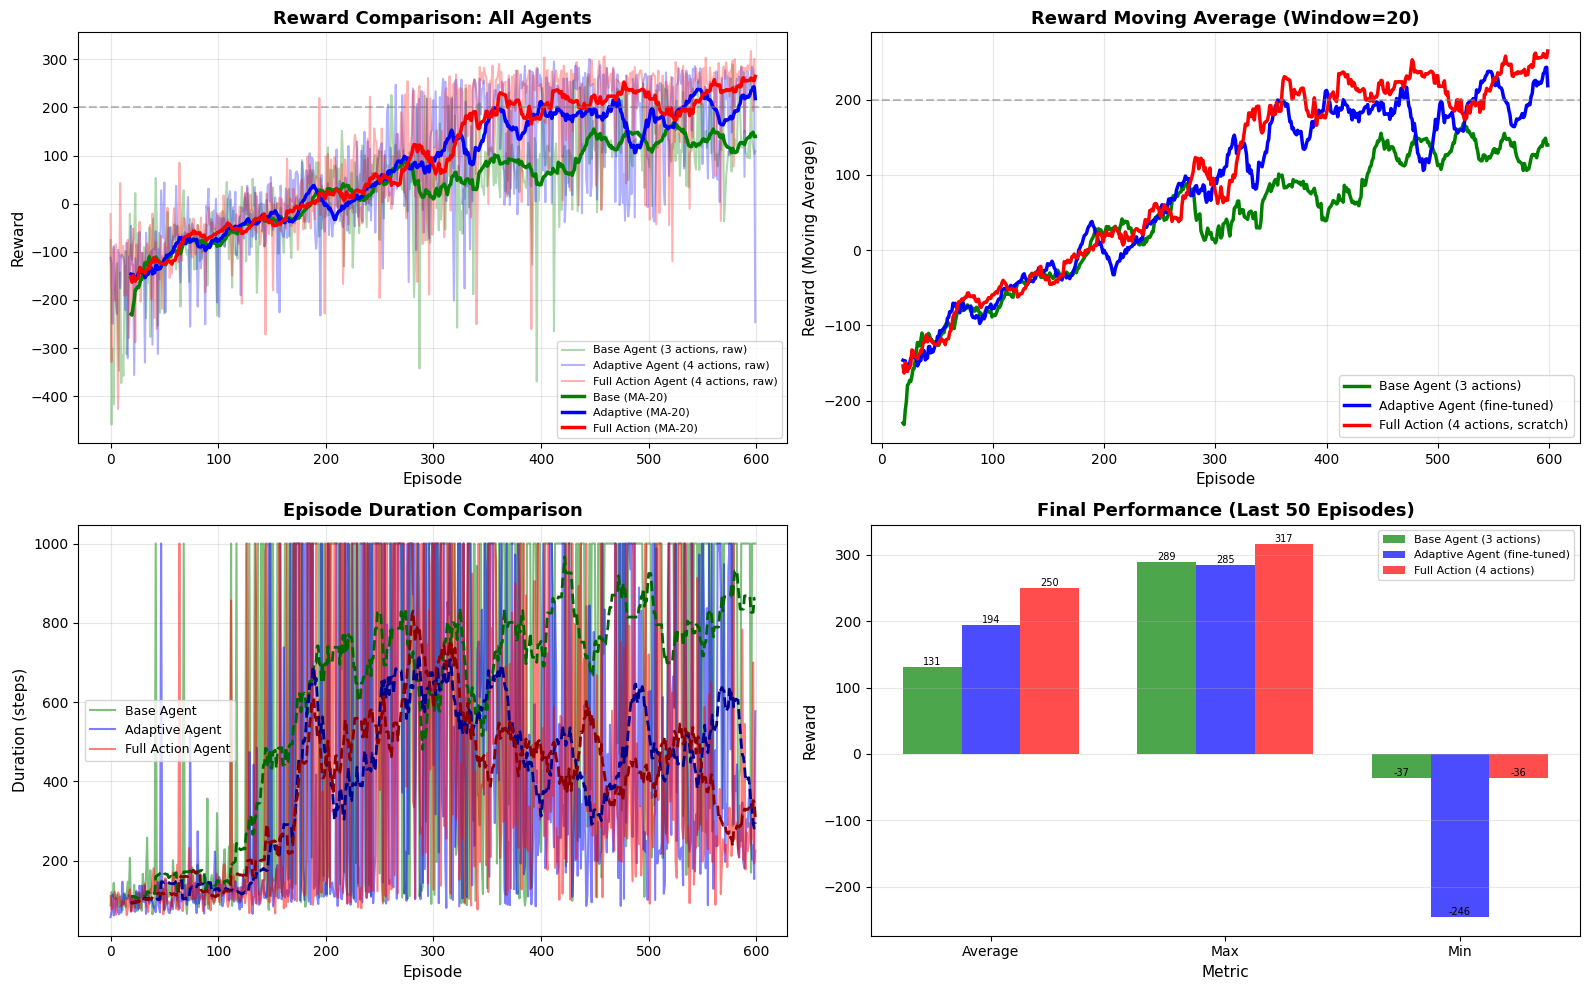


TRAINING COMPARISON: BASE vs ADAPTIVE vs FULL ACTION AGENTS

Metric                             Base (3 act)  Adaptive (fine)     Full (4 act)
-------------------------------------------------------------------------------------
Average Reward (last 50)                 131.13           194.34           250.20
Max Reward (last 50)                     288.86           284.82           317.26
Min Reward (last 50)                     -36.62          -246.06           -35.73

Overall Average Reward                      35.45              75.82              93.03
Overall Max Reward                         288.86             300.45             317.26
Overall Min Reward                        -458.74            -355.88            -426.37

Avg Episode Duration (last 50)             862.34             488.66             304.82
Success Rate (last 50, >200)                   9%                33%                45%

WINNER: Full Action Agent (From Scratch)
   vs Base:     +90.8%
   vs Adaptive: +

In [46]:
import matplotlib.pyplot as plt

# Prepare data
reward_list_base_agent = reward_list  # Base agent (3 actions from scratch)
episode_durations_base_agent = episode_durations

reward_list_adaptive_agent = adaptive_agent.reward_list
episode_durations_adaptive_agent = adaptive_agent.episode_duration
action_map_adaptive_agent = adaptive_agent.full_action_map

reward_list_full_action_agent = full_action_agent.reward_list
episode_durations_full_action_agent = full_action_agent.episode_duration

# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

window = 20

# ============ Plot 1: Raw Rewards Comparison ============
ax1 = axes[0, 0]
ax1.plot(reward_list_base_agent, alpha=0.3, color='green', label='Base Agent (3 actions, raw)')
ax1.plot(reward_list_adaptive_agent, alpha=0.3, color='blue', label='Adaptive Agent (4 actions, raw)')
ax1.plot(reward_list_full_action_agent, alpha=0.3, color='red', label='Full Action Agent (4 actions, raw)')

# Moving averages
if len(reward_list_base_agent) >= window:
    moving_avg_base = np.convolve(reward_list_base_agent, np.ones(window)/window, mode='valid')
    ax1.plot(range(window-1, len(reward_list_base_agent)), moving_avg_base, 
             color='green', lw=2.5, label=f'Base (MA-{window})')

if len(reward_list_adaptive_agent) >= window:
    moving_avg_adaptive = np.convolve(reward_list_adaptive_agent, np.ones(window)/window, mode='valid')
    ax1.plot(range(window-1, len(reward_list_adaptive_agent)), moving_avg_adaptive, 
             color='blue', lw=2.5, label=f'Adaptive (MA-{window})')

if len(reward_list_full_action_agent) >= window:
    moving_avg_full = np.convolve(reward_list_full_action_agent, np.ones(window)/window, mode='valid')
    ax1.plot(range(window-1, len(reward_list_full_action_agent)), moving_avg_full, 
             color='red', lw=2.5, label=f'Full Action (MA-{window})')

ax1.set_xlabel('Episode', fontsize=11)
ax1.set_ylabel('Reward', fontsize=11)
ax1.set_title('Reward Comparison: All Agents', fontsize=13, fontweight='bold')
ax1.legend(fontsize=8, loc='lower right')
ax1.grid(alpha=0.3)
ax1.axhline(y=200, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)

# ============ Plot 2: Moving Average Only (Cleaner View) ============
ax2 = axes[0, 1]
if len(reward_list_base_agent) >= window:
    ax2.plot(range(window-1, len(reward_list_base_agent)), moving_avg_base, 
             color='green', lw=2.5, label='Base Agent (3 actions)')

if len(reward_list_adaptive_agent) >= window:
    ax2.plot(range(window-1, len(reward_list_adaptive_agent)), moving_avg_adaptive, 
             color='blue', lw=2.5, label='Adaptive Agent (fine-tuned)')

if len(reward_list_full_action_agent) >= window:
    ax2.plot(range(window-1, len(reward_list_full_action_agent)), moving_avg_full, 
             color='red', lw=2.5, label='Full Action (4 actions, scratch)')

ax2.set_xlabel('Episode', fontsize=11)
ax2.set_ylabel('Reward (Moving Average)', fontsize=11)
ax2.set_title(f'Reward Moving Average (Window={window})', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.axhline(y=200, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)

# ============ Plot 3: Episode Duration Comparison ============
ax3 = axes[1, 0]
ax3.plot(episode_durations_base_agent, alpha=0.5, color='green', label='Base Agent')
ax3.plot(episode_durations_adaptive_agent, alpha=0.5, color='blue', label='Adaptive Agent')
ax3.plot(episode_durations_full_action_agent, alpha=0.5, color='red', label='Full Action Agent')

# Moving average for durations
if len(episode_durations_base_agent) >= window:
    duration_ma_base = np.convolve(episode_durations_base_agent, np.ones(window)/window, mode='valid')
    ax3.plot(range(window-1, len(episode_durations_base_agent)), duration_ma_base, 
             color='darkgreen', lw=2, linestyle='--')

if len(episode_durations_adaptive_agent) >= window:
    duration_ma_adaptive = np.convolve(episode_durations_adaptive_agent, np.ones(window)/window, mode='valid')
    ax3.plot(range(window-1, len(episode_durations_adaptive_agent)), duration_ma_adaptive, 
             color='darkblue', lw=2, linestyle='--')

if len(episode_durations_full_action_agent) >= window:
    duration_ma_full = np.convolve(episode_durations_full_action_agent, np.ones(window)/window, mode='valid')
    ax3.plot(range(window-1, len(episode_durations_full_action_agent)), duration_ma_full, 
             color='darkred', lw=2, linestyle='--')

ax3.set_xlabel('Episode', fontsize=11)
ax3.set_ylabel('Duration (steps)', fontsize=11)
ax3.set_title('Episode Duration Comparison', fontsize=13, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

# ============ Plot 4: Final Performance Summary (Bar Chart) ============
ax4 = axes[1, 1]

# Calculate statistics for last 50 episodes
stats_base = {
    'Avg': np.mean(reward_list_base_agent[-50:]),
    'Max': max(reward_list_base_agent[-50:]),
    'Min': min(reward_list_base_agent[-50:])
}

stats_adaptive = {
    'Avg': np.mean(reward_list_adaptive_agent[-50:]),
    'Max': max(reward_list_adaptive_agent[-50:]),
    'Min': min(reward_list_adaptive_agent[-50:])
}

stats_full = {
    'Avg': np.mean(reward_list_full_action_agent[-50:]),
    'Max': max(reward_list_full_action_agent[-50:]),
    'Min': min(reward_list_full_action_agent[-50:])
}

x = np.arange(3)
width = 0.25

bars1 = ax4.bar(x - width, [stats_base['Avg'], stats_base['Max'], stats_base['Min']], 
                width, label='Base Agent (3 actions)', color='green', alpha=0.7)
bars2 = ax4.bar(x, [stats_adaptive['Avg'], stats_adaptive['Max'], stats_adaptive['Min']], 
                width, label='Adaptive Agent (fine-tuned)', color='blue', alpha=0.7)
bars3 = ax4.bar(x + width, [stats_full['Avg'], stats_full['Max'], stats_full['Min']], 
                width, label='Full Action (4 actions)', color='red', alpha=0.7)

ax4.set_xlabel('Metric', fontsize=11)
ax4.set_ylabel('Reward', fontsize=11)
ax4.set_title('Final Performance (Last 50 Episodes)', fontsize=13, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(['Average', 'Max', 'Min'])
ax4.legend(fontsize=8)
ax4.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.0f}',
                ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('training_comparison_all_agents.png', dpi=150, bbox_inches='tight')
plt.show()

# Print detailed comparison statistics
print("\n" + "="*85)
print("TRAINING COMPARISON: BASE vs ADAPTIVE vs FULL ACTION AGENTS")
print("="*85)

print(f"\n{'Metric':<30} {'Base (3 act)':>16} {'Adaptive (fine)':>16} {'Full (4 act)':>16}")
print("-"*85)

# Last 50 episodes statistics
print(f"{'Average Reward (last 50)':<30} {stats_base['Avg']:>16.2f} {stats_adaptive['Avg']:>16.2f} {stats_full['Avg']:>16.2f}")
print(f"{'Max Reward (last 50)':<30} {stats_base['Max']:>16.2f} {stats_adaptive['Max']:>16.2f} {stats_full['Max']:>16.2f}")
print(f"{'Min Reward (last 50)':<30} {stats_base['Min']:>16.2f} {stats_adaptive['Min']:>16.2f} {stats_full['Min']:>16.2f}")

# Overall statistics
print(f"\n{'Overall Average Reward':<30} {np.mean(reward_list_base_agent):>18.2f} {np.mean(reward_list_adaptive_agent):>18.2f} {np.mean(reward_list_full_action_agent):>18.2f}")
print(f"{'Overall Max Reward':<30} {max(reward_list_base_agent):>18.2f} {max(reward_list_adaptive_agent):>18.2f} {max(reward_list_full_action_agent):>18.2f}")
print(f"{'Overall Min Reward':<30} {min(reward_list_base_agent):>18.2f} {min(reward_list_adaptive_agent):>18.2f} {min(reward_list_full_action_agent):>18.2f}")

# Episode duration statistics
print(f"\n{'Avg Episode Duration (last 50)':<30} {np.mean(episode_durations_base_agent[-50:]):>18.2f} {np.mean(episode_durations_adaptive_agent[-50:]):>18.2f} {np.mean(episode_durations_full_action_agent[-50:]):>18.2f}")

# Success rate (episodes with reward > 200)
success_base = sum(1 for r in reward_list_base_agent[-50:] if r > 200)
success_adaptive = sum(1 for r in reward_list_adaptive_agent[-50:] if r > 200)
success_full = sum(1 for r in reward_list_full_action_agent[-50:] if r > 200)
print(f"{'Success Rate (last 50, >200)':<30} {success_base:>17}% {success_adaptive:>17}% {success_full:>17}%")

# Winner - Compare all three agents
print("\n" + "="*80)
best_avg = max(stats_base['Avg'], stats_adaptive['Avg'], stats_full['Avg'])

if stats_base['Avg'] == best_avg:
    print(f"WINNER: Base Agent (3 Actions)")
    if stats_adaptive['Avg'] != 0:
        vs_adaptive = ((stats_base['Avg'] - stats_adaptive['Avg']) / abs(stats_adaptive['Avg'])) * 100
        print(f"   vs Adaptive: +{vs_adaptive:.1f}%")
    if stats_full['Avg'] != 0:
        vs_full = ((stats_base['Avg'] - stats_full['Avg']) / abs(stats_full['Avg'])) * 100
        print(f"   vs Full:     +{vs_full:.1f}%")
elif stats_adaptive['Avg'] == best_avg:
    improvement = ((stats_adaptive['Avg'] - stats_full['Avg']) / abs(stats_full['Avg'])) * 100
    vs_base = ((stats_adaptive['Avg'] - stats_base['Avg']) / abs(stats_base['Avg'])) * 100
    print(f"WINNER: Adaptive Agent (Fine-tuned)")
    print(f"   vs Base:     +{vs_base:.1f}%")
    print(f"   vs Full:     +{improvement:.1f}%")
else:
    vs_base = ((stats_full['Avg'] - stats_base['Avg']) / abs(stats_base['Avg'])) * 100
    vs_adaptive = ((stats_full['Avg'] - stats_adaptive['Avg']) / abs(stats_adaptive['Avg'])) * 100
    print(f"WINNER: Full Action Agent (From Scratch)")
    print(f"   vs Base:     +{vs_base:.1f}%")
    print(f"   vs Adaptive: +{vs_adaptive:.1f}%")
print("="*70)